In [1]:
import pandas as pd

In [62]:
file = '/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/DA/product/sentinel3a_sentinel3b_cryosat2/MIZ_filter_2/csv/sea_ice_thickness-sh-150r-epsg6932_141-2026-08-19_12-49-32/SOSIMBA-L2P-SITHICK-SRAL_SENTINEL3A_SRAL_SENTINEL3B_SIRAL_CRYOSAT2-SH_DA_R-20200103-fv100.csv'

df = pd.read_csv(file, skiprows=1)

In [59]:
df.dt_days

0          0
1          0
2          0
3          0
4          0
          ..
236621    15
236622    15
236623    15
236624    15
236625    15
Name: dt_days, Length: 236626, dtype: int64

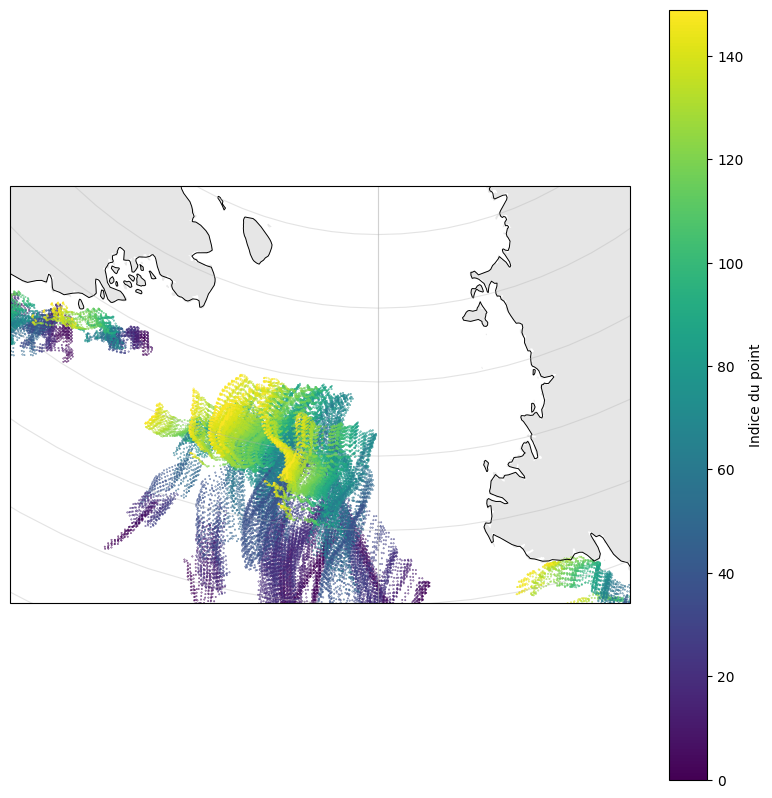

In [65]:
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import geopandas as gpd
# À adapter si ton CRS source est différent.
df = df.copy()

df["geometry"] = df["geometry"].apply(
    lambda geom: wkt.loads(geom) if isinstance(geom, str) else geom
)
gdf = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:6932")

# MULTIPOINT -> un enregistrement par point
points = gdf.explode(index_parts=False).reset_index(names="trajectory_id")
points["point_idx"] = points.groupby("trajectory_id").cumcount()

# Filtre mer de Ross : environ 160°E → 150°W, au sud de 70°S
points_ll = points.to_crs(4326)



# Identifiants des trajectoires dont le PREMIER point est dans Ross
ids_ross = points_ll.loc[
    (points_ll["point_idx"] == 0) & (points_ll["dt_days"]>=0),
    "trajectory_id"
].unique()

# Toutes les positions de ces trajectoires, même hors de Ross ensuite
trajectoires_ross = points_ll[
    points_ll["trajectory_id"].isin(ids_ross)
].copy()


# Carte polaire avec fond terre / côte
projection = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={"projection": projection})

ax.set_extent([160, 210, -80, -70], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="#ffffff")
ax.add_feature(cfeature.LAND, facecolor="#e6e6e6")
ax.coastlines(resolution="50m", linewidth=0.7)
ax.gridlines(draw_labels=False, alpha=.35)

# Trajectoires en gris


scatter = ax.scatter(
    trajectoires_ross.geometry.x,
    trajectoires_ross.geometry.y,
    c=trajectoires_ross["point_idx"],
    cmap="viridis",
    s=0.1,
    transform=ccrs.PlateCarree(),
)

fig.colorbar(scatter, ax=ax, label="Indice du point")
plt.show()

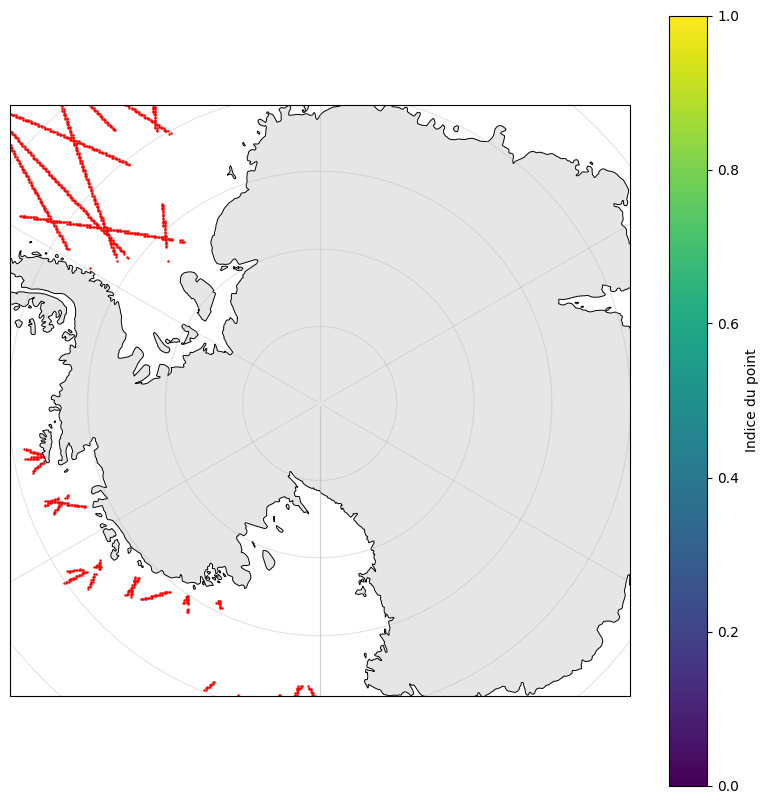

In [68]:
import geopandas as gpd
from shapely import wkt
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature



# Carte polaire avec fond terre / côte
projection = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(10, 10),
                       subplot_kw={"projection": projection})

ax.set_extent([160, -85, -150, -70] , crs=ccrs.PlateCarree())
ax.add_feature(cfeature.OCEAN, facecolor="#ffffff")
ax.add_feature(cfeature.LAND, facecolor="#e6e6e6")
ax.coastlines(resolution="50m", linewidth=0.7)
ax.gridlines(draw_labels=False, alpha=.35)

# Trajectoires en gris

points_initiaux = trajectoires_ross[
    trajectoires_ross["point_idx"] == 0
]

scatter = ax.scatter(
    points_initiaux.geometry.x,
    points_initiaux.geometry.y,
    c="red",       # ou c=points_initiaux["point_idx"], mais tous valent 0
    s=3,
    transform=ccrs.PlateCarree(),
    linewidths=0,
)

fig.colorbar(scatter, ax=ax, label="Indice du point")
plt.show()

In [39]:
import xarray as xr
s3a = xr.open_dataset('/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/SOSIMBA/cdr/sentinel3a/v5p1-preview1-ss/sh/l2p_release/2020/05/SOSIMBA-SEAICE-L2P-SITHICK-SRAL_SENTINEL3A-SH-20200531-fv5p0.nc') 
cs2 = xr.open_dataset('/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/SOSIMBA/cdr/cryosat2/v5p1-preview1-ss/sh/l2p_release/2020/05/SOSIMBA-SEAICE-L2P-SITHICK-SIRAL_CRYOSAT2-SH-20200531-fv5p0.nc') 
s3b = xr.open_dataset('/cluster/projects/108541-SO-SIMBA/data_tmp/output_data/SOSIMBA/cdr/sentinel3b/v5p1-preview1-ss/sh/l2p_release/2020/05/SOSIMBA-SEAICE-L2P-SITHICK-SRAL_SENTINEL3B-SH-20200531-fv5p0.nc') 

In [41]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

def plot_ross_nc(ds, variable="sea_ice_thickness", taille_points=2):
    """
    fichiers : liste de chemins vers les fichiers .nc
    variable : par ex. 'sea_ice_thickness', 'sea_ice_freeboard',
               'radar_freeboard' ou 'snow_depth'
    """

    # Ouvre et rassemble les fichiers selon la dimension time
    #datasets = [xr.open_dataset(fichier) for fichier in fichiers]
    #ds = xr.concat(datasets, dim="time")

    lon = ds["lon"].values
    lat = ds["lat"].values
    valeur = ds[variable].values

    # Uniformise les longitudes dans [-180, 180]
    lon = ((lon + 180) % 360) - 180

    # Mer de Ross : 160°E -> 150°W, 85°S -> 70°S
    masque = (
        np.isfinite(lon) &
        np.isfinite(lat) &
        np.isfinite(valeur) &
        (lat >= -85) & (lat <= -70) &
        ((lon >= 160) | (lon <= -150))
    )

    projection = ccrs.SouthPolarStereo()
    fig, ax = plt.subplots(
        figsize=(10, 10),
        subplot_kw={"projection": projection}
    )

    ax.set_extent([160, 210, -85, -70], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.OCEAN, facecolor="#cfe8f3")
    ax.add_feature(cfeature.LAND, facecolor="#e8e2d0")
    ax.coastlines(resolution="50m", linewidth=0.7)
    ax.gridlines(alpha=0.3)

    points = ax.scatter(
        lon[masque],
        lat[masque],
        c=valeur[masque],
        s=taille_points,
        cmap="viridis",
        linewidths=0,
        transform=ccrs.PlateCarree(),
    )

    fig.colorbar(points, ax=ax, label=variable)
    ax.set_title(f"Mer de Ross — {variable} ({masque.sum()} points)")
    plt.show()

    ds.close()

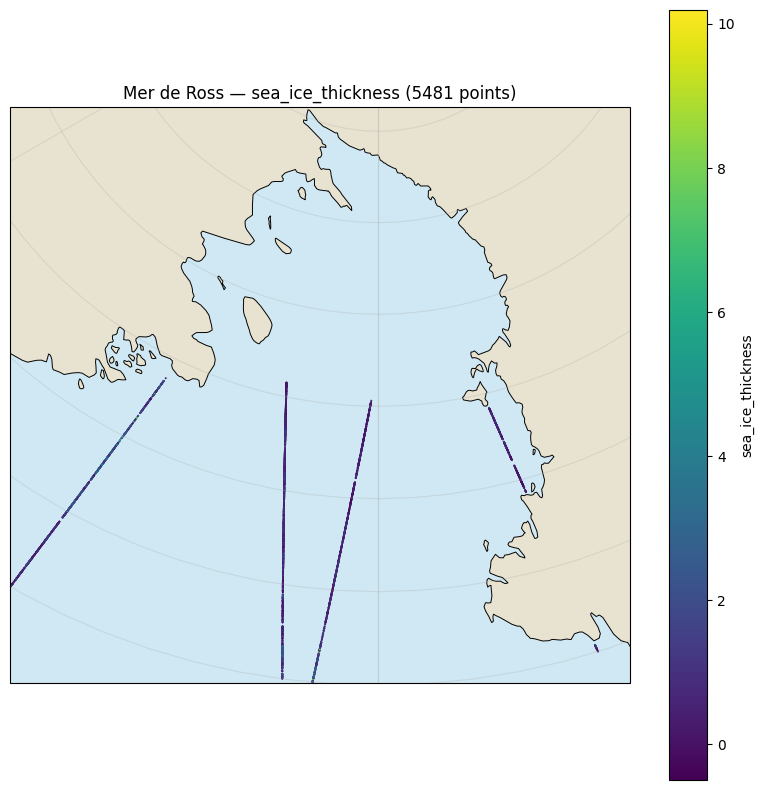

In [44]:
plot_ross_nc(cs2, variable="sea_ice_thickness", taille_points=2)